In [53]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from math import sqrt
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split


# Dataset selection
I chose the Bike Sharing Demand Dataset as it had ~10k entries. The dataset is a regression task aiming to predict the rental count at a specific time. The bike sharing dataset contains temporal features and other related dependancies like temperature and humidity, making it a good candidate for a neural net that can handle those complex relationships. It also having a size of 10k is good for my custom neuralnet to be able to efficiently train and evaluate on as a larger dataset may be too computationally intensive.

link: https://www.kaggle.com/competitions/bike-sharing-demand/data?select=train.csv

# Neural Net from Scratch

In [49]:
# Custom neural net implementation
class NeuralNetwork:
    def __init__(self, layerSizes, learningRate=0.01, seed=45):
        # Initialization function for the neural network
        np.random.seed(seed)
        self.layerSizes = layerSizes
        self.lr = learningRate
        self.L = len(layerSizes) - 1

        self.W = []
        self.b = []

        for l in range(self.L):
            # Initialize weights and biases
            Wl = np.random.randn(layerSizes[l+1], layerSizes[l]) * np.sqrt(1/layerSizes[l])
            bl = np.zeros((layerSizes[l+1], 1))
            self.W.append(Wl)
            self.b.append(bl)

    def relu(self, Z):
        # Return the max for each element of Z between 0 and z
        return np.maximum(0, Z)

    def reluDeriv(self, Z):
        # Per element of Z return 1 if its greater than 0 and 0 if not
        return (Z > 0).astype(float)

    def forward(self, X):
        # Forward function t compute the output
        # Save A and Z values for layers (needed for backprop)
        aVals = [X]
        zVals = []

        A = X
        # Loop through each layer and compute the Z and activations
        for l in range(self.L - 1):
            Z = self.W[l] @ A + self.b[l]
            A = self.relu(Z)
            zVals.append(Z)
            aVals.append(A)

        # Output layer because regression, activation is the same (identity func)
        ZL = self.W[self.L - 1] @ A + self.b[self.L - 1]
        zVals.append(ZL)
        aVals.append(ZL)

        return ZL, aVals, zVals

    def cost(self, yHat, Y):
        # MSE
        return np.mean((yHat - Y) ** 2)

    def backward(self, yHat, Y, aVals, zVals):
        m = Y.shape[1]

        dW = [None] * self.L
        db = [None] * self.L

        # Cost func derivative
        dZ = 2 * (yHat - Y) / m

        # Back track through layers
        for l in reversed(range(self.L)):
            aPrev = aVals[l]
            # Calculate weights and bias derivatives for each layer
            dW[l] = dZ @ aPrev.T
            db[l] = np.sum(dZ, axis=1, keepdims=True)

            if l > 0:
                # Update the accumulated derivative (shared part of deriv) so far for next layer
                daPrev = self.W[l].T @ dZ
                dZ = daPrev * self.reluDeriv(zVals[l-1])

        return dW, db

    def update(self, dW, db):
        # Apply the updates to every weight and bias
        for l in range(self.L):
            self.W[l] -= self.lr * dW[l]
            self.b[l] -= self.lr * db[l]

    def train_sgd(self, X, Y, epochs=100):
        # Stochastic Gradient Descent
        n = X.shape[1]

        for epoch in range(epochs):
            perm = np.random.permutation(n)

            for i in perm:
                # features are stored in rows to make matrix multiplication easier for everything else
                # Need to transpose X and Y when putting them into the train method
                xi = X[:, i:i+1]
                yi = Y[:, i:i+1]

                # Train
                yHat, aVals, zVals = self.forward(xi)
                dW, db = self.backward(yHat, yi, aVals, zVals)
                self.update(dW, db)

            # Print progress
            if epoch % 10 == 0:
                yHatAll, _, _ = self.forward(X)
                print(f"Epoch {epoch} Loss: {self.cost(yHatAll, Y):.4f}")

    def train_batch(self, X, Y, epochs=100, batch_size=None):
        # Can set mini-batch if given a batch size
        n = X.shape[1]
        if batch_size is None:
            batch_size = n  # full batch

        for epoch in range(epochs):
            # get random permutations and then batches for the data
            perm = np.random.permutation(n)
            for start in range(0, n, batch_size):
                end = start + batch_size
                batch_idx = perm[start:end]

                # features are stored in rows to make matrix multiplication easier for everything else
                # Need to transpose X and Y when putting them into the train method
                X_batch = X[:, batch_idx]
                Y_batch = Y[:, batch_idx]

                # Train
                yHat, aVals, zVals = self.forward(X_batch)
                dW, db = self.backward(yHat, Y_batch, aVals, zVals)
                self.update(dW, db)

            # Print progress
            if epoch % 100 == 0:
                yHatAll, _, _ = self.forward(X)
                print(f"Epoch {epoch} Loss: {self.cost(yHatAll, Y):.4f}")

    def predict(self, X):
        yHat, _, _ = self.forward(X)
        return yHat


# Mount dataset

In [8]:
# Mount google drive
from google.colab import drive
import os
drive.mount('/content/drive')
# Change to the directory to my datasets
os.chdir('/content/drive/MyDrive/bike-sharing-demand')
print(os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['sampleSubmission.csv', 'test.csv', 'train.csv']


# Preprocessing

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# load the data
df = pd.read_csv("train.csv")

# Preprocessing
df = df.dropna()
df = df.drop_duplicates()

# Change date into numerical features
df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday

# Drop the original date
df = df.drop(columns=["datetime"])

# Drop feature as casual and registered sum to target
df = df.drop(columns=["casual", "registered"])

# One hot encode the categorical features
df = pd.get_dummies(df, columns=["season", "weather"], drop_first=True)

# Separate features and target
# Convert to float64 to ensure numerical operations work correctly in the neural network
X = df.drop(columns=["count"]).values.astype(np.float64)
Y = df["count"].values.reshape(-1, 1).astype(np.float64)

# Train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Feature Scaling
# Standardize numerical features for better neural network performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fit on train and transform
X_test = scaler.transform(X_test)       # Transform test using train's scaler

# Transpose for neural network (mentioned why input needed above)
X_train = X_train.T
X_test  = X_test.T
Y_train = Y_train.T
Y_test  = Y_test.T

# SGD

In [51]:
# Initialize Neural Net
layer_sizes = [X_train.shape[0], 32, 16, 1]
nn = NeuralNetwork(layerSizes=layer_sizes, learningRate=0.001)

# Training
print("Training SGD")
nn.train_sgd(X_train, Y_train, epochs=200)

# Predict
Y_pred_train = nn.predict(X_train)
Y_pred_test  = nn.predict(X_test)

# Compute training & test error (MSE)
train_mse = mean_squared_error(Y_train.T, Y_pred_train.T)
test_mse  = mean_squared_error(Y_test.T, Y_pred_test.T)

print(f"Final Train MSE: {train_mse:.4f}")
print(f"Final Test MSE : {test_mse:.4f}")

Training SGD
Epoch 0 Loss: 7253515733678017622095955433018438426718181418713674882155864344635049590784513839453765763851465916306948096.0000
Epoch 10 Loss: 32783.1110
Epoch 20 Loss: 32785.6837
Epoch 30 Loss: 32779.3815
Epoch 40 Loss: 32776.9025
Epoch 50 Loss: 32774.8229
Epoch 60 Loss: 32765.5966
Epoch 70 Loss: 32764.9959
Epoch 80 Loss: 32856.4651
Epoch 90 Loss: 32800.4127
Epoch 100 Loss: 32810.4353
Epoch 110 Loss: 32846.1466
Epoch 120 Loss: 32761.8534
Epoch 130 Loss: 32873.2691
Epoch 140 Loss: 32761.1380
Epoch 150 Loss: 32786.2547
Epoch 160 Loss: 32809.4057
Epoch 170 Loss: 32761.7998
Epoch 180 Loss: 32828.2503
Epoch 190 Loss: 32781.7342
Final Train MSE: 32761.7767
Final Test MSE : 33007.6852


# Batch GD

In [50]:
# Initialize Neural Net
layer_sizes = [X_train.shape[0], 32, 16, 1]
nn2 = NeuralNetwork(layerSizes=layer_sizes, learningRate=0.001)

# Training
print("Training Batch")
nn2.train_batch(X_train, Y_train, epochs=3000)

# Predict
Y_pred_train = nn2.predict(X_train)
Y_pred_test  = nn2.predict(X_test)

# Compute training & test error (MSE)
train_mse = mean_squared_error(Y_train.T, Y_pred_train.T)
test_mse  = mean_squared_error(Y_test.T, Y_pred_test.T)

print(f"Final Train MSE: {train_mse:.4f}")
print(f"Final Test MSE : {test_mse:.4f}")

Training Batch
Epoch 0 Loss: 68738.0252
Epoch 100 Loss: 58071.6821
Epoch 200 Loss: 49720.4824
Epoch 300 Loss: 44124.7523
Epoch 400 Loss: 40374.5180
Epoch 500 Loss: 37857.6369
Epoch 600 Loss: 36175.8516
Epoch 700 Loss: 35041.6948
Epoch 800 Loss: 34289.2187
Epoch 900 Loss: 33785.0194
Epoch 1000 Loss: 33447.1778
Epoch 1100 Loss: 33220.8032
Epoch 1200 Loss: 33069.1129
Epoch 1300 Loss: 32967.4673
Epoch 1400 Loss: 32899.3538
Epoch 1500 Loss: 32853.7020
Epoch 1600 Loss: 32823.1011
Epoch 1700 Loss: 32802.5788
Epoch 1800 Loss: 32788.7047
Epoch 1900 Loss: 32779.3584
Epoch 2000 Loss: 32771.2348
Epoch 2100 Loss: 32680.5851
Epoch 2200 Loss: 32481.1129
Epoch 2300 Loss: 32382.6767
Epoch 2400 Loss: 30118.0724
Epoch 2500 Loss: 19988.0643
Epoch 2600 Loss: 17368.5768
Epoch 2700 Loss: 14856.9546
Epoch 2800 Loss: 15606.1431
Epoch 2900 Loss: 17338.4825
Final Train MSE: 16977.4372
Final Test MSE : 16898.5411


# Testing my NeuralNetwork Class

I tested my class using both stochastic gradient descent and batch gradient descent. Stochastic gradient descent converged much quicker than batch gradient descent did however it got stuck at a much worse error (I did not go farther as stochastic ended up being pretty slow due to inefficiencies with python loops natively). Batch Gradient Descent did end up being pretty fast for my dataset due to its relatively small size for a neural net. However, the final mean squared error for batch gradient descent was much better at the end of training. Batch gradient descent also ended up much more stable with it only starting to increase error towards the end (likely overfitting) compared to stochastic gradient descent where the error would be constantly increasing and decreasing.

# Part 2 - 2 layer NN with DL framework


## EDA


Dataset shape: (10886, 16)
Columns: Index(['holiday', 'workingday', 'temp', 'atemp', 'humidity', 'windspeed',
       'count', 'month', 'hour', 'weekday', 'season_2', 'season_3', 'season_4',
       'weather_2', 'weather_3', 'weather_4'],
      dtype='object')
Missing values: holiday       0
workingday    0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
month         0
hour          0
weekday       0
season_2      0
season_3      0
season_4      0
weather_2     0
weather_3     0
weather_4     0
dtype: int64
Duplicates: 1


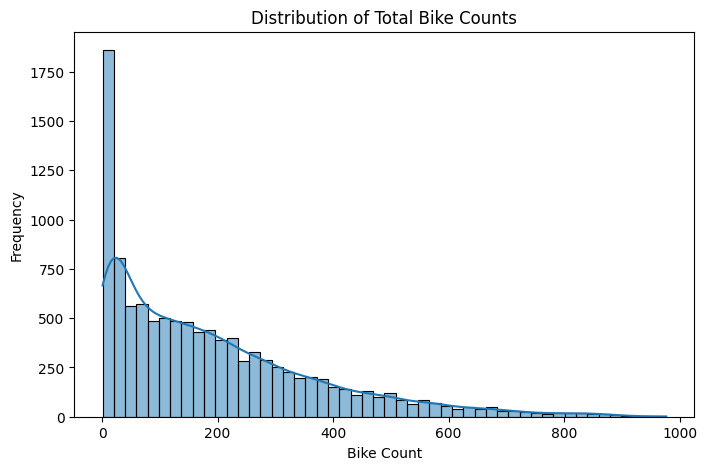

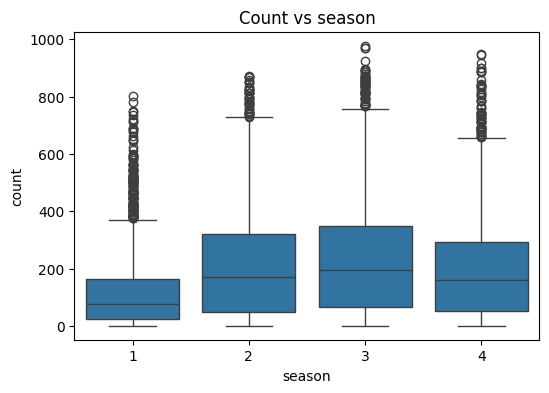

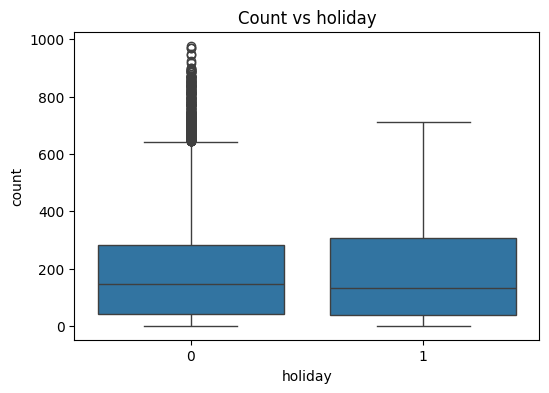

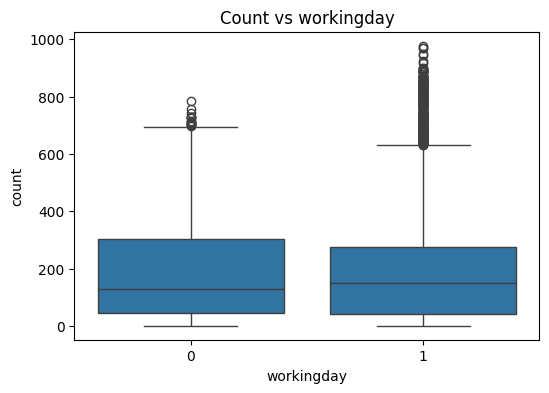

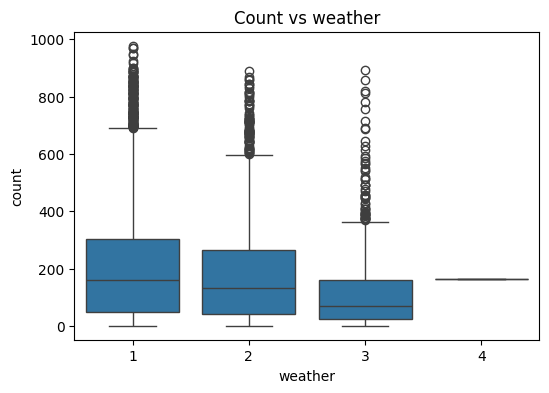

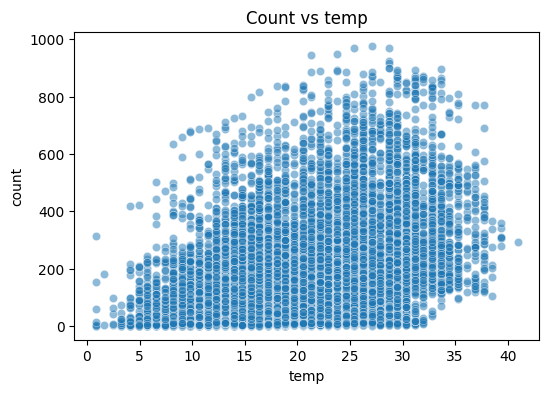

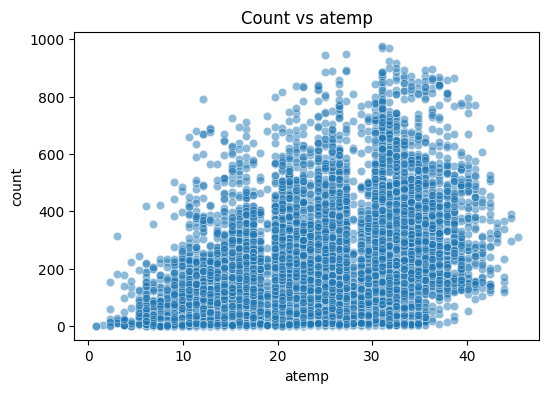

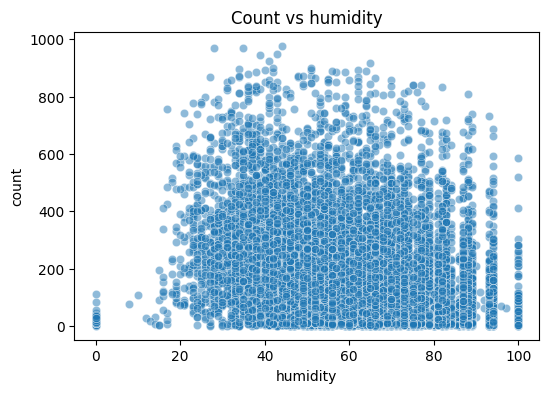

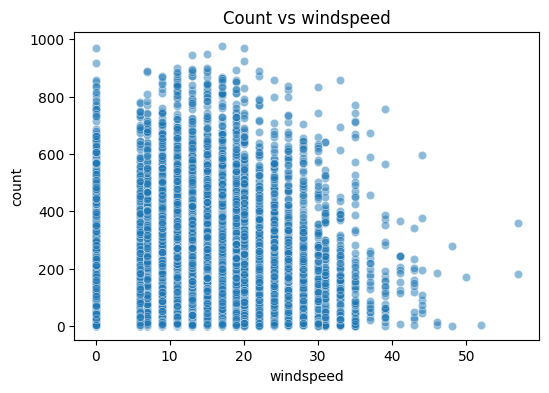

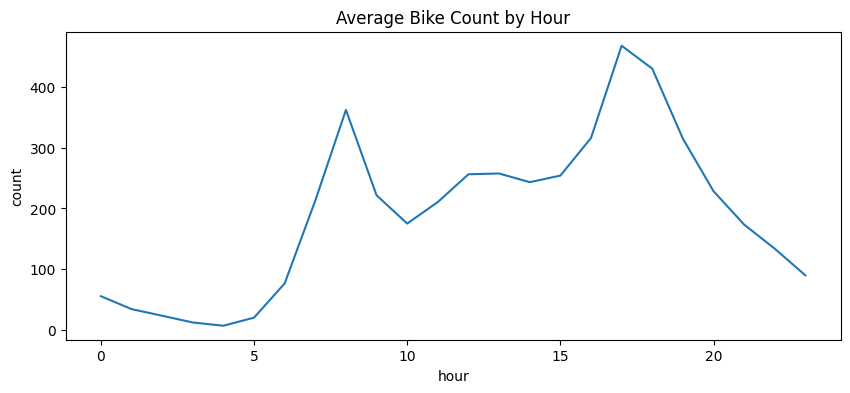

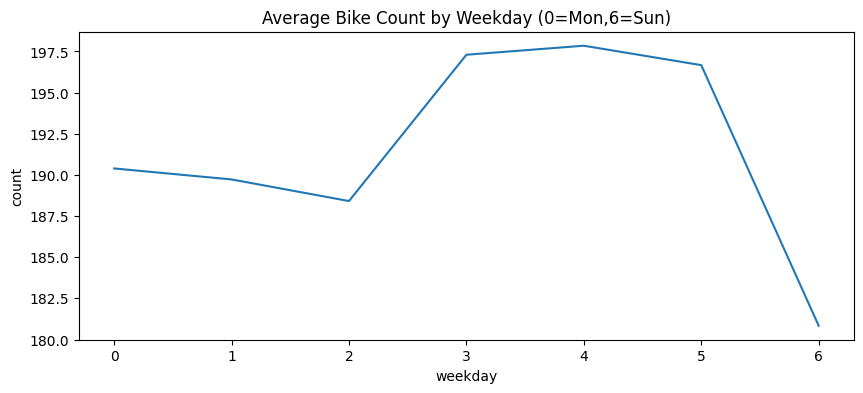

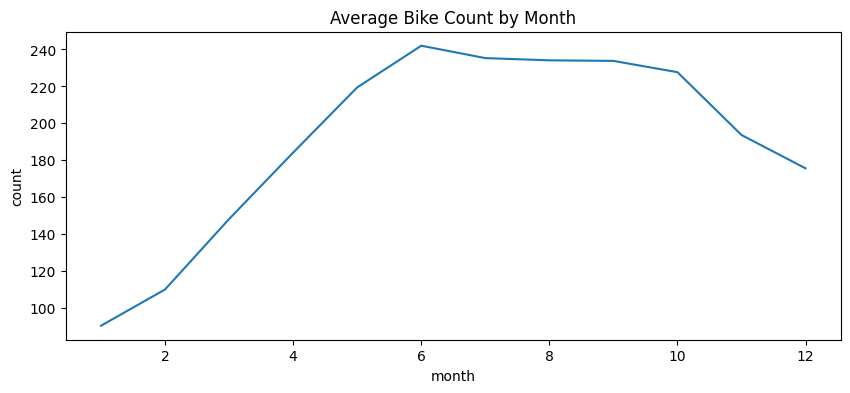

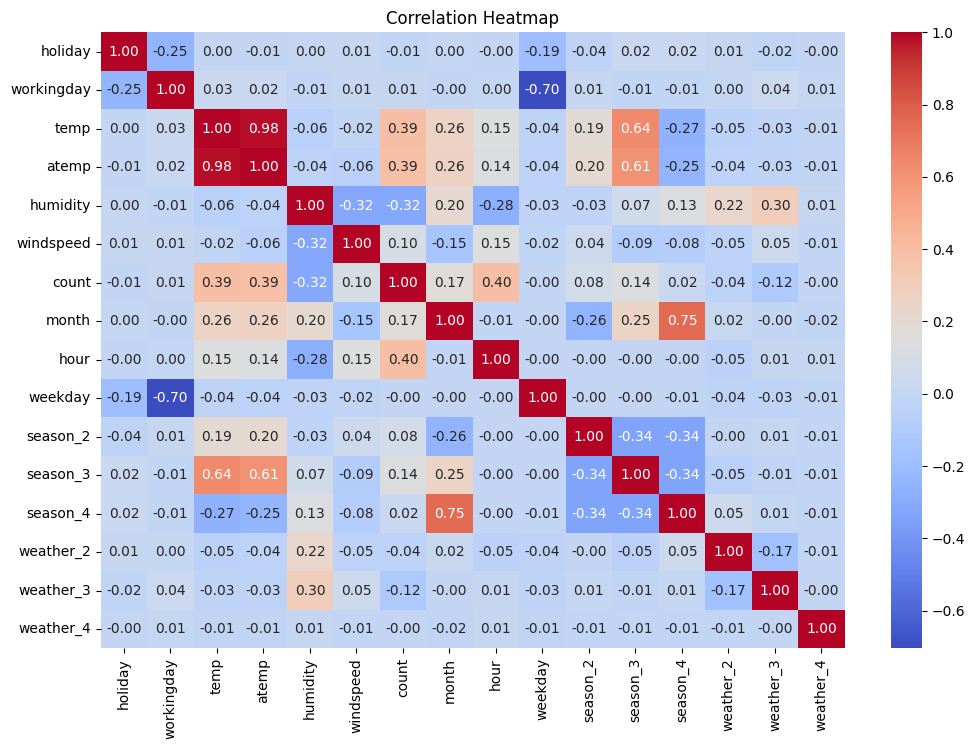

In [58]:
df_plot = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns)
print("Missing values:", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# target distribution
plt.figure(figsize=(8,5))
sns.histplot(df_plot['count'], bins=50, kde=True)
plt.title("Distribution of Total Bike Counts")
plt.xlabel("Bike Count")
plt.ylabel("Frequency")
plt.show()

# categorical distributions vs count
categorical_cols_original = ['season', 'holiday', 'workingday', 'weather']
for col in categorical_cols_original:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y='count', data=df_plot)
    plt.title(f"Count vs {col}")
    plt.show()

# continuous distributions vs count
continuous_cols = ['temp','atemp','humidity','windspeed']
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y='count', data=df_plot, alpha=0.5)
    plt.title(f"Count vs {col}")
    plt.show()

# Get the dates and times from datetime
df_plot['datetime'] = pd.to_datetime(df_plot['datetime'])
df_plot['hour'] = df_plot['datetime'].dt.hour
df_plot['weekday'] = df_plot['datetime'].dt.weekday
df_plot['month'] = df_plot['datetime'].dt.month

# Hourly trend
plt.figure(figsize=(10,4))
sns.lineplot(x='hour', y='count', data=df_plot.groupby('hour')['count'].mean().reset_index())
plt.title("Average Bike Count by Hour")
plt.show()

# Weekday trend
plt.figure(figsize=(10,4))
sns.lineplot(x='weekday', y='count', data=df_plot.groupby('weekday')['count'].mean().reset_index())
plt.title("Average Bike Count by Weekday (0=Mon,6=Sun)")
plt.show()

# Monthly trend
plt.figure(figsize=(10,4))
sns.lineplot(x='month', y='count', data=df_plot.groupby('month')['count'].mean().reset_index())
plt.title("Average Bike Count by Month")
plt.show()


# For correlation heatmap
# Using only numeric columns
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Preprocessing already done earlier

# NN implementation from DL framework

Resources used to learn pytorch

Official tutorial:
https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html

Autograd for backpropagation:
https://pytorch.org/docs/stable/autograd.html

Optimization:
https://pytorch.org/docs/stable/optim.html

Loss functions:
https://pytorch.org/docs/stable/nn.html#loss-functions

Why I need these:
- official tutorial provides the basic syntax for building a neural network
- autograd replaces manual backpropogation. This allows us to not need to compute dW and dB manually.
- The optimizer (we used Adam) allows us to skip implementing update and gradient descent functions. It also allows for faster convergence and dynamic learning rates through optimizers like Adam
- pytorch has built in cost functions like MSE so we do not need to implement our own

In [64]:
# Convert X and Y matrices to tensors
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

# Train/val/test split
# val can also be called dev
n_samples = X.shape[0]
train_size = int(0.7 * n_samples)
val_size = int(0.15 * n_samples)
test_size = n_samples - train_size - val_size

dataset = TensorDataset(X, Y)
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size)
test_loader  = DataLoader(test_set, batch_size=batch_size)

# Define the neural network class
class TwoLayerNN(nn.Module):
    def __init__(self, input_dim, hidden1=32, hidden2=16):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        # regression output layer
        self.out = nn.Linear(hidden2, 1)

    def forward(self, x):
        # forward pass
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.out(x)
        return x

# Initialize network
input_dim = X.shape[1]
model = TwoLayerNN(input_dim)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train the NN
n_epochs = 100
for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Compute validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            y_pred = model(xb)
            val_loss += criterion(y_pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch} Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

# Evaluate the NN
model.eval()
test_loss = 0
with torch.no_grad():
    for xb, yb in test_loader:
        y_pred = model(xb)
        test_loss += criterion(y_pred, yb).item() * xb.size(0)
test_loss /= len(test_loader.dataset)
print(f"Test MSE: {test_loss:.4f}")

Epoch 0 Train MSE: 24904.0595 | Val MSE: 21224.2425
Epoch 10 Train MSE: 16102.2067 | Val MSE: 15733.2083
Epoch 20 Train MSE: 14654.9784 | Val MSE: 14685.6187
Epoch 30 Train MSE: 12828.0749 | Val MSE: 12266.0913
Epoch 40 Train MSE: 11557.3164 | Val MSE: 11633.0821
Epoch 50 Train MSE: 10944.0996 | Val MSE: 13068.0596
Epoch 60 Train MSE: 10412.8947 | Val MSE: 10742.2991
Epoch 70 Train MSE: 9677.3038 | Val MSE: 10374.7488
Epoch 80 Train MSE: 9169.1283 | Val MSE: 10643.3925
Epoch 90 Train MSE: 8744.6746 | Val MSE: 10213.7628
Test MSE: 9398.6135


# Task 3
In task 2 describe how you selected the hyperparameters. What was the
rationale behind the technique you used? Did you use regularization? Why, or why not? Did you use
an optimization algorithm? Why or why not?

For the hyper parameters, I selected to have 2 hidden layers with 32 neurons in the first layer and 16 in the second layer. I chose this as the dataset is not large so having more layers and more nodes per layers would have been overkill and likely lead to overfitting. I experimented with the different neuron counts and 32 -> 16 achieved the best balance on convergence, training error, and generalization.

For the learning rate and optimization, I chose to use Adam and a learning rate of 0.01. 0.01 is a standard learning rate for Adam and ended up being the best one for convergence from my testing.

The batch sizes were chosen to be 32 to compromize on the variance in the updates while also allowing for more frequent updates. From what I researched online 32 seemed to be a common compromise for datasets of my size.

I set the number if epochs to 100 to allow for convergence but also end early enough to avoid overfitting as my dataset is relatively small for a neuralnetwork and would be prone to overfitting.